# Forecasting the GEO Killer-Electron Radiation Environment
### Team SOLAR JEDI · ISRO BAH 2026 — Colab runner

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mridulkhanna03-web/isro-hackathon/blob/main/notebooks/run_on_colab.ipynb)

**Phase 1** (daily d+1/2/3 forecast) runs top-to-bottom with no data setup. **Phase 2**
(5-min 45min/6h/12h nowcast on OMNI) and **Phase 3** (the same nowcast **retrained on raw
DSCOVR L1** solar wind + an operational risk score) are further down and each need their
high-cadence data pulled from Drive first. Colab already ships PyTorch / scikit-learn /
pandas, so no `uv` / `.venv-modeling` here.

## 1. Get the code
Private repo → clone with a GitHub token (fine-grained, *Contents: Read*). Store the token
once in **Colab Secrets** ( in the left sidebar) as **`GH_PAT`** with *Notebook access* on;
the cell reads it from `userdata` (and falls back to a prompt if the secret isn't set).

In [1]:
# GitHub PAT (fine-grained, Contents: Read). Store it once in Colab Secrets:
#   left sidebar  -> add a secret named GH_PAT, paste the token, enable "Notebook access".
try:
    from google.colab import userdata
    token = userdata.get('GH_PAT')
except Exception:                     # secret missing / access not granted / not on Colab
    from getpass import getpass
    token = getpass('GH_PAT secret not found — paste a GitHub token (Contents: Read): ')

!git clone https://{token}@github.com/mridulkhanna03-web/isro-hackathon.git
%cd isro-hackathon
!pip install -q xgboost

Cloning into 'isro-hackathon'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 139 (delta 34), reused 119 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 2.88 MiB | 7.92 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/isro-hackathon


## Phase 1 — daily forecaster (train → evaluate → forecast → view)

In [2]:
!python modeling/data_prep.py --check     # optional QA: shapes, balance, leakage checks
!python modeling/train.py                 # walk-forward training (~3-5 min)
!python modeling/evaluate.py              # metrics table + plots
!python modeling/predict.py               # forecast the next 3 days

Cleaned frame: 4383 rows x 25 cols, 2004-01-01 .. 2015-12-31
Feature cols (model input): 23  |  tabular cols (B): 153
Residual missing % after clean: none

Event threshold (global percentile=90.0): log10=8.480  (physical cross-check log10=8.0)
  d+1: events 450/4382 = 10.3% positive
  d+2: events 450/4381 = 10.3% positive
  d+3: events 450/4380 = 10.3% positive

Walk-forward folds (expanding train -> predict year):
  test 2009: train=1827 days, test=365 days
  test 2010: train=2192 days, test=365 days
  test 2011: train=2557 days, test=365 days
  test 2012: train=2922 days, test=366 days
  test 2013: train=3288 days, test=365 days
  test 2014: train=3653 days, test=365 days
  test 2015: train=4018 days, test=365 days

Leakage checks passed: targets NaN only at tail, lag features NaN only at head.
[fold 2009] thr=8.670  fusion=(0.7,0.15,0.15)  val_auc=0.912
[fold 2010] thr=8.680  fusion=(1.0,0.0,0.0)  val_auc=-1.000
[fold 2011] thr=8.610  fusion=(1.0,0.0,0.0)  val_auc=0.934
[fold 2012] 

```
horizon              model   TSS   HSS   AUC PRAUC Brier    PE  RMSE     R
    d+1 Ensemble(B+C+phys) 0.792 0.543 0.958 0.515 0.025 0.713 0.581 0.858
    d+1    P_ML(B+C blend) 0.874 0.459 0.971 0.536 0.025 0.713 0.581 0.858
    d+1      C-only (LSTM) 0.608 0.140 0.871 0.265 0.069 0.385 0.851 0.671
    d+1   B-only (XGBoost) 0.898 0.382 0.979 0.577 0.025 0.668 0.625 0.847
    d+1        Persistence 0.562 0.562 0.781 0.349 0.030 0.783 0.505 0.892
    d+1        Climatology 0.000 0.000 0.500 0.035 0.034 0.000 1.085 0.000
    d+1    Recurrence(27d) 0.172 0.175 0.586 0.070 0.055 0.033 1.067 0.515
    d+2 Ensemble(B+C+phys) 0.618 0.178 0.890 0.294 0.033 0.509 0.760 0.739
    d+2    P_ML(B+C blend) 0.714 0.256 0.905 0.309 0.033 0.509 0.760 0.739
    d+2      C-only (LSTM) 0.590 0.143 0.862 0.276 0.083 0.296 0.910 0.593
    d+2   B-only (XGBoost) 0.755 0.250 0.930 0.313 0.035 0.417 0.828 0.695
    d+2        Persistence 0.332 0.332 0.666 0.149 0.045 0.547 0.730 0.773
    d+2        Climat

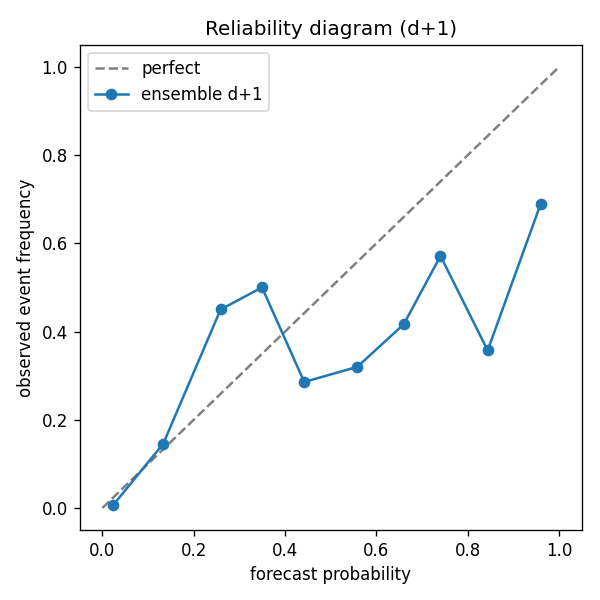

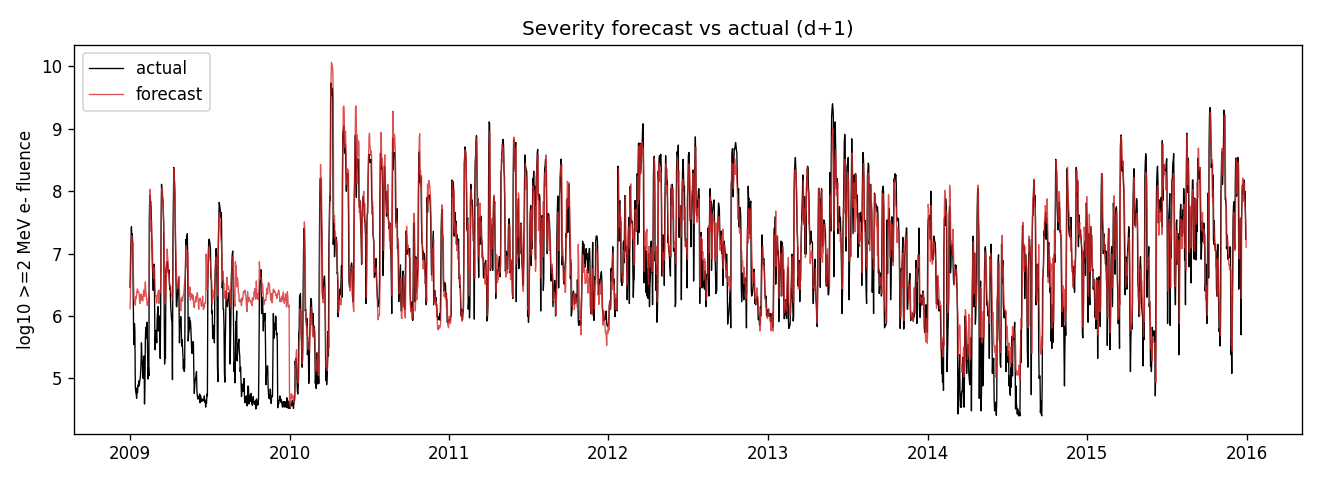

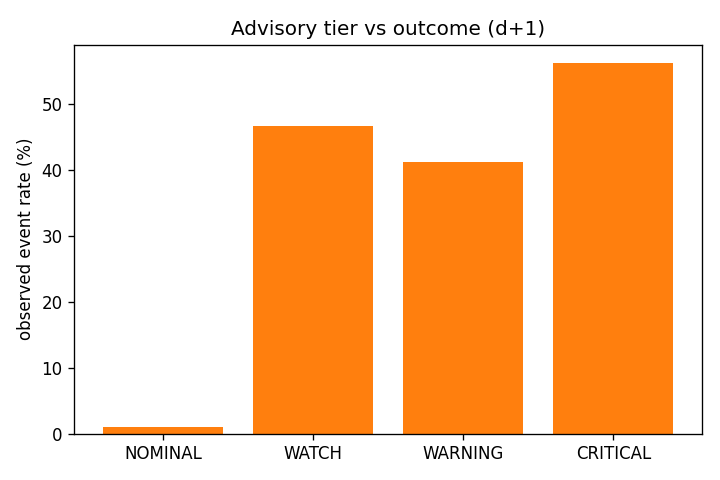

In [3]:
print(open('modeling/artifacts/metrics_table.md').read())
from IPython.display import Image, display
for p in ['reliability_d1.png', 'severity_d1.png', 'advisory_d1.png']:
    display(Image(f'modeling/artifacts/{p}'))

---
# Phase 2 — high-cadence 5-min nowcast (optional, heavier)

Forecasts the >=2 MeV electron flux at **45-min / 6-h / 12-h** from OMNI solar wind + GOES
electrons. The 5-min data (~113 MB) is **too large for git** (>GitHub's 100 MB limit), so get
it one of two ways below, then train.

### Get the data : Download the pre-built merged CSV
Share `spaceweather_5min_2004_2015.csv` via Google Drive and paste its file id below.

In [4]:
!pip install -q gdown
import os; os.makedirs('phase2/data', exist_ok=True)
FILE_ID = '1HY1JwhKNKmdoJ7e4SKiKe1vbNAm4k1eR'   # <-- paste the Google Drive file id for spaceweather_5min_2004_2015.csv
!gdown {FILE_ID} -O phase2/data/spaceweather_5min_2004_2015.csv

Downloading...
From (original): https://drive.google.com/uc?id=1HY1JwhKNKmdoJ7e4SKiKe1vbNAm4k1eR
From (redirected): https://drive.google.com/uc?id=1HY1JwhKNKmdoJ7e4SKiKe1vbNAm4k1eR&confirm=t&uuid=01027a10-34a8-4701-b332-c9e8f2c5148c
To: /content/isro-hackathon/phase2/data/spaceweather_5min_2004_2015.csv
100% 118M/118M [00:01<00:00, 59.2MB/s]


### Train, plot, and forecast (high cadence) — training ~15 min on Colab CPU

built: 1262304 rows, tab 95 cols
  Bin] trained (pos_weight=2.33)
  B[6h] trained (pos_weight=2.33)
  B[12h] trained (pos_weight=2.33)
    lstm epoch 1/8 done
    lstm epoch 2/8 done
    lstm epoch 3/8 done
    lstm epoch 4/8 done
    lstm epoch 5/8 done
    lstm epoch 6/8 done
    lstm epoch 7/8 done
    lstm epoch 8/8 done
  C (LSTM) trained + predicted

horizon         model   TSS   AUC PRAUC Brier     PE  RMSE      R
  45min Ensemble(B+C) 0.914 0.993 0.984 0.031  0.949 0.170  0.974
  45min   B-only(XGB) 0.916 0.994 0.986 0.029  0.945 0.176  0.972
  45min  C-only(LSTM) 0.877 0.987 0.974 0.048  0.922 0.209  0.963
  45min   Persistence 0.897 0.948 0.884 0.044  0.939 0.186  0.970
  45min   Climatology 0.000 0.500 0.307 0.213 -0.308 0.859 -0.000
     6h Ensemble(B+C) 0.740 0.942 0.872 0.094  0.712 0.403  0.844
     6h   B-only(XGB) 0.746 0.946 0.893 0.090  0.683 0.423  0.827
     6h  C-only(LSTM) 0.595 0.892 0.798 0.140  0.590 0.481  0.777
     6h   Persistence 0.544 0.772 0.568 0.192  

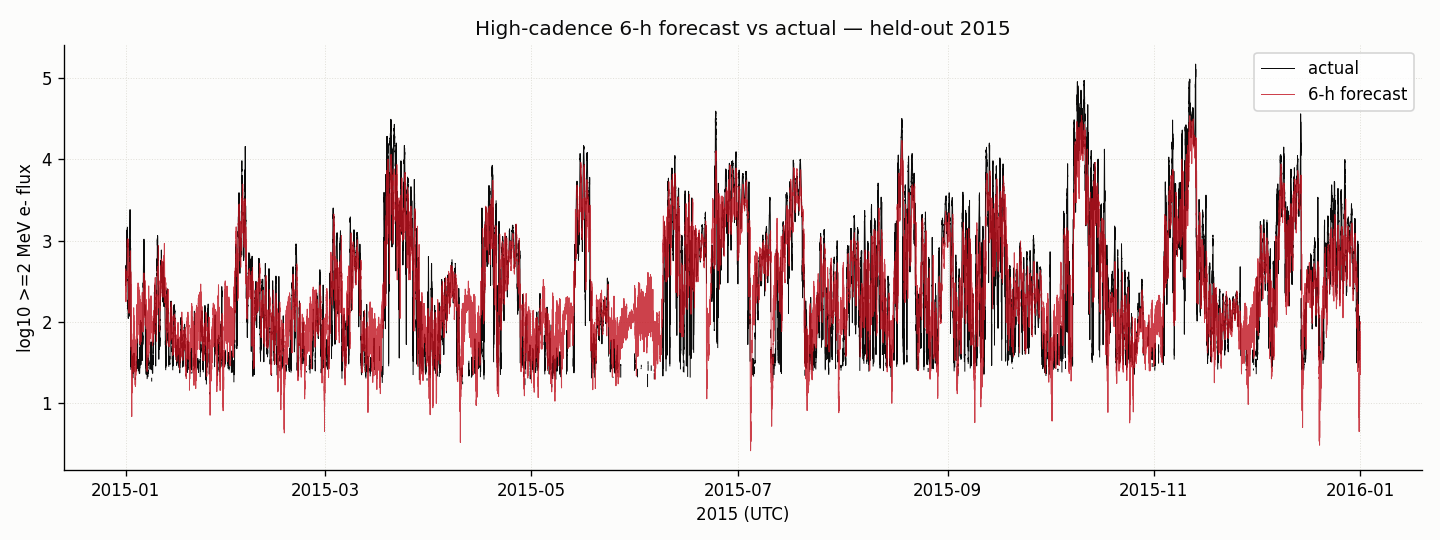

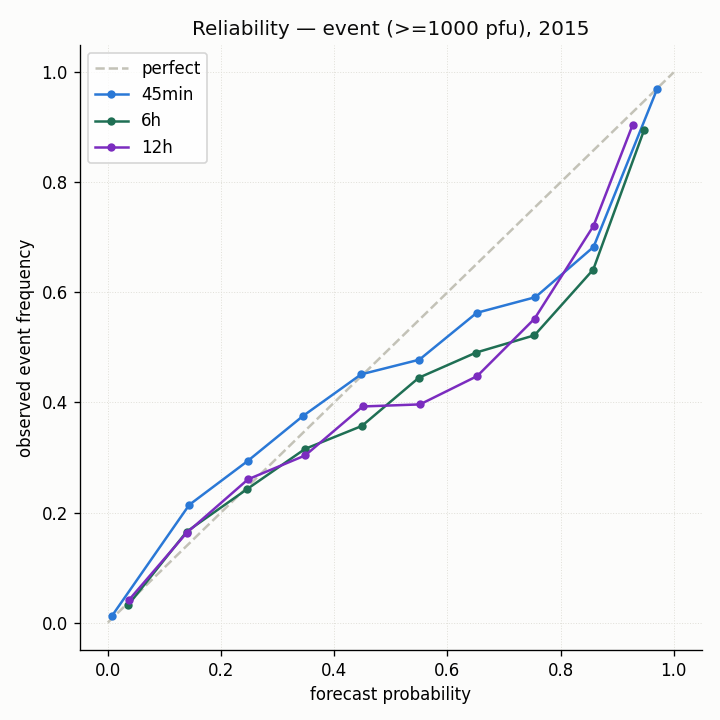

In [5]:
!python phase2/hc_train.py           # trains B+C, prints test-2015 metrics, saves artifacts
!python phase2/hc_plots.py           # forecast-vs-actual + reliability plots
!python phase2/hc_predict.py         # live forecast at 45min/6h/12h from the latest row
from IPython.display import Image, display
for p in ['hc_pred_vs_actual_2015.png', 'hc_reliability_2015.png']:
    display(Image(f'phase2/artifacts/{p}'))

---
# Phase 3 — real-time L1 nowcast (DSCOVR) · Version 1 (offline)

Retrains the Phase-2 B+C ensemble on **raw DSCOVR L1 solar wind** (speed, density, temperature,
IMF Bz/By/|B|) instead of OMNI, so the model can later run live on the real-time L1 feed. Same
target (GOES ≥2 MeV electron flux) and horizons (**45-min / 6-h / 12-h**, event = ≥1000 pfu),
plus an operational **Risk Score → NOMINAL / WATCH / WARNING / CRITICAL**.

On the held-out DSCOVR test window the L1 nowcast clearly beats persistence and the gap widens
with horizon (6 h TSS 0.73 vs 0.54; 12 h 0.73 vs 0.35).

### Get the data : download only the shared Drive folder
No Drive mount (that would expose your whole Drive). `gdown --folder` fetches **only the one
shared folder** below — set it to **Anyone with the link · Viewer** in Drive — and nothing else
in your account is touched. The folder just needs to contain
`spaceweather_dscovr_5min_2016_2019.csv` (~26 MB).

In [6]:
!pip install -q gdown
import glob, os, shutil
os.makedirs('phase3/data', exist_ok=True)

# Your shared project folder (Anyone with the link · Viewer) — ONLY this folder is accessed:
FOLDER = 'https://drive.google.com/drive/folders/1V7K_cedHYfK7kdjXQBvQcnOS9GJmvabL'
!gdown --folder "{FOLDER}" -O phase3/_drive_dl --remaining-ok

CSV = 'spaceweather_dscovr_5min_2016_2019.csv'
hits = glob.glob(f'phase3/**/{CSV}', recursive=True)
assert hits, f'{CSV} not found — upload it to that folder and set it to "Anyone with the link"'
shutil.copy(hits[0], f'phase3/data/{CSV}')
print('loaded ->', f'phase3/data/{CSV}')

Retrieving folder contents
Processing file 1PDYDR2nvDLU8Kbrbocwtuln3FZBCXaGi ace_epam_daily.xlsx
Processing file 1ZBgwNcSLML4HQ-7ECM_qcGR-ZVr9tcbx circle_sheet.xlsx
Processing file 1udDUIShyeDcybzhBnaa8z3Fk8e1rpVYv electron_fluence_2mev_2004_2015.csv
Processing file 1G0pZ-_mU8qZXgSyBYUPfmIdHB_6EE2xjHr731nLWs2o geomagnetic_kpapdst_daily_2004_2015
Processing file 1T9F2EqneIy3GHeIsHPXPfabQ86MYWEhk goes_proton_fluence.xlsx
Processing file 1r19boAXc_cLH87wcslrSqFk0PnAOjy-k polygon_data.xlsx
Processing file 1O6G4dVvQzAFOzXMeIm7jjpXC_ZH84Hbe SN_d_tot_2004-2015.xlsx
Processing file 1tFYYD2IRYaCVhvZAbjo1IJZXvQRjkMX1 solar_proton_events_1976_2017.csv
Processing file 1Iq6YzG5pJM57nYou7VGrVZF1w_0vofOS solar_proton_events_timeseries.png
Processing file 1596eXBMy87KJxZvLOEoAwqVfobk3A4Vg space_weather_daily_final.xlsx
Processing file 1HY1JwhKNKmdoJ7e4SKiKe1vbNAm4k1eR spaceweather_5min_2004_2015.csv
Processing file 1vXzkfuo8GY-u9ZvnSYaklZcvbpxWP1j8 spaceweather_dscovr_5min_2016_2019.csv
Retrieving fol

### Retrain on raw DSCOVR L1, plot, forecast + score — training ~10–15 min on Colab CPU
`retrain.py` reuses the Phase-2 model code unchanged (the DSCOVR table has the same schema),
retrains on a 2016-06→2019 split, and writes `phase3/artifacts/`. `predict.py` prints the
per-horizon forecast **plus the Risk Score `R` and operational condition** (NOMINAL/WATCH/
WARNING/CRITICAL) for the latest row.

training on spaceweather_dscovr_5min_2016_2019.csv
DSCOVR split -> train 166176 | val 52128 | test 64800  (val>=2018-01-01, test>=2018-07-01)
built: 283104 rows, tab 95 cols
  Bin] trained (pos_weight=0.72)
  B[6h] trained (pos_weight=0.72)
  B[12h] trained (pos_weight=0.72)
    lstm epoch 1/8 done
    lstm epoch 2/8 done
    lstm epoch 3/8 done
    lstm epoch 4/8 done
    lstm epoch 5/8 done
    lstm epoch 6/8 done
    lstm epoch 7/8 done
    lstm epoch 8/8 done
  C (LSTM) trained + predicted

horizon         model   TSS   AUC PRAUC Brier     PE  RMSE     R
  45min Ensemble(B+C) 0.927 0.995 0.991 0.027  0.977 0.116 0.988
  45min   B-only(XGB) 0.927 0.995 0.992 0.025  0.975 0.119 0.988
  45min  C-only(LSTM) 0.755 0.947 0.912 0.106  0.708 0.408 0.909
  45min   Persistence 0.911 0.956 0.909 0.040  0.971 0.128 0.986
  45min   Climatology 0.000 0.500 0.352 0.280 -0.353 0.879 0.000
     6h Ensemble(B+C) 0.730 0.940 0.912 0.096  0.810 0.329 0.901
     6h   B-only(XGB) 0.730 0.943 0.913 0.096

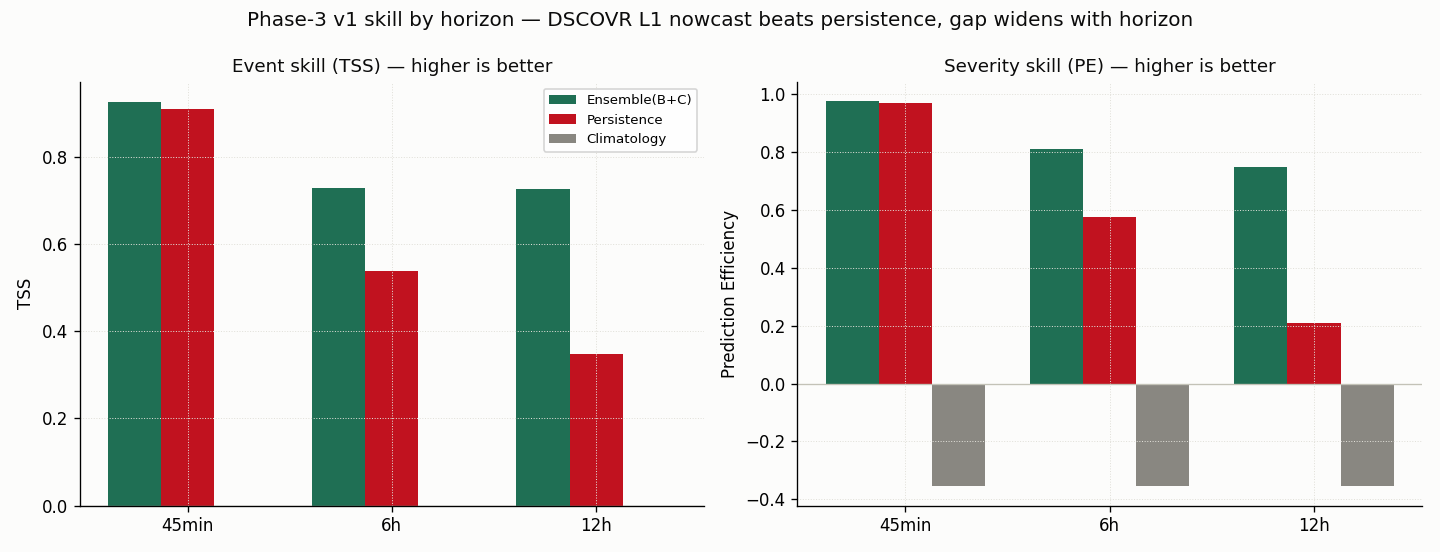

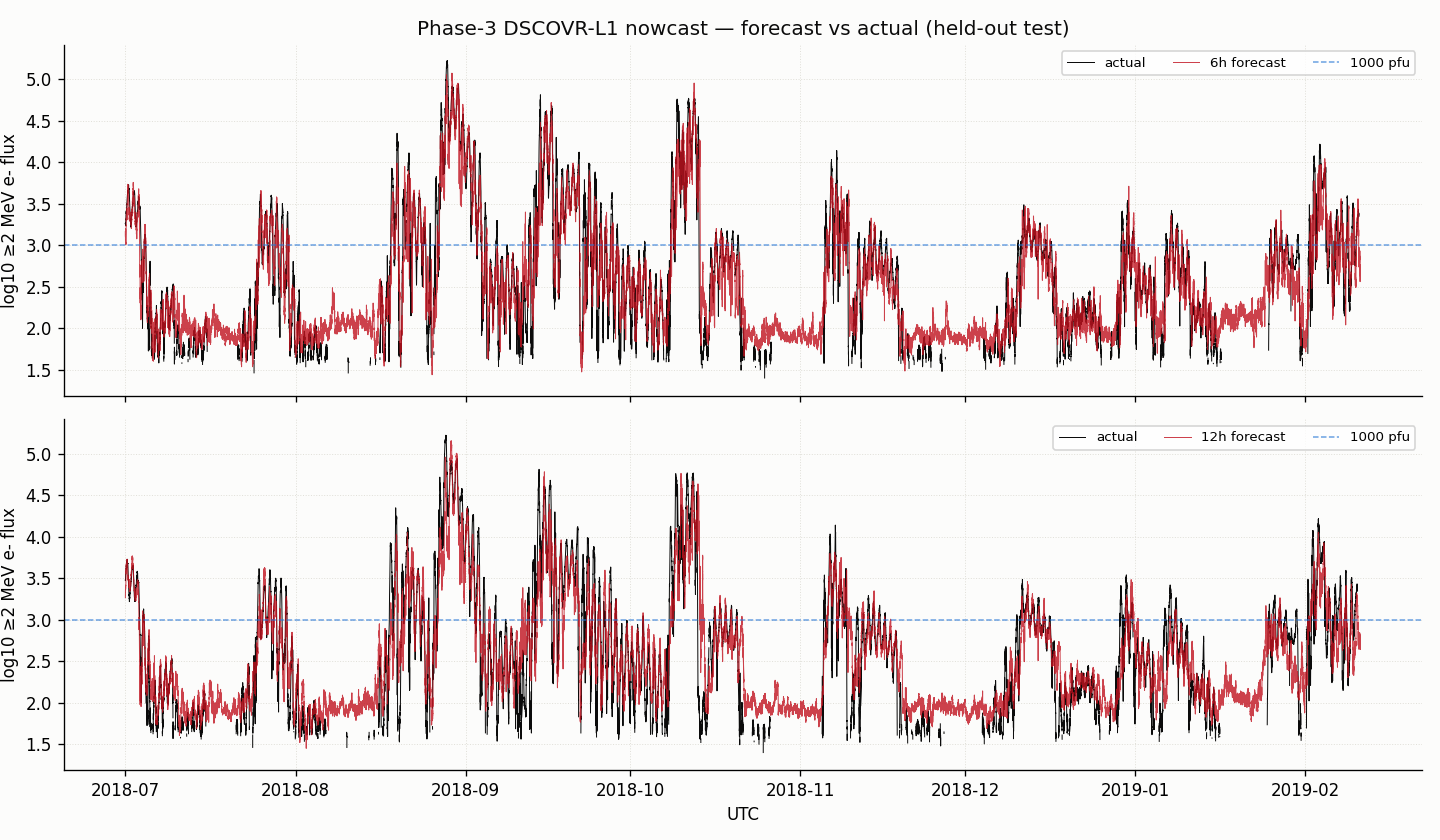

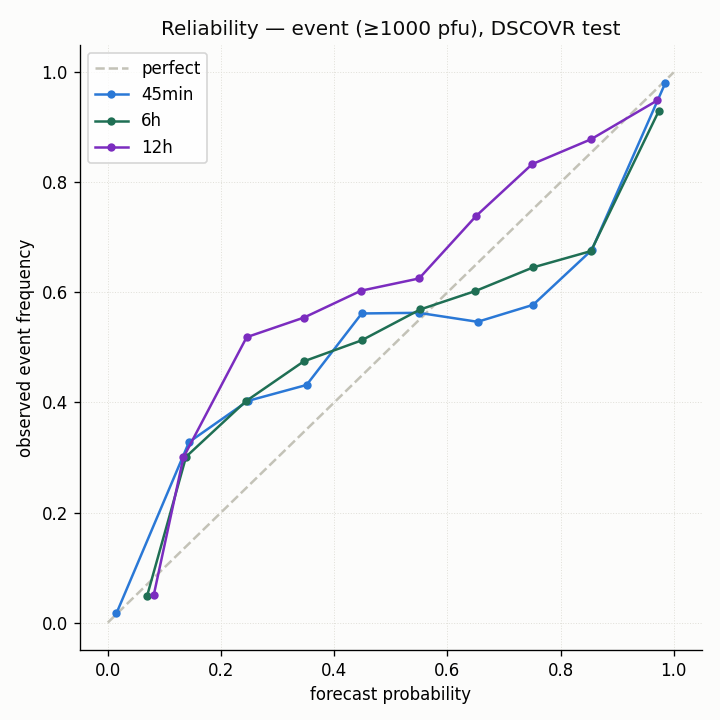

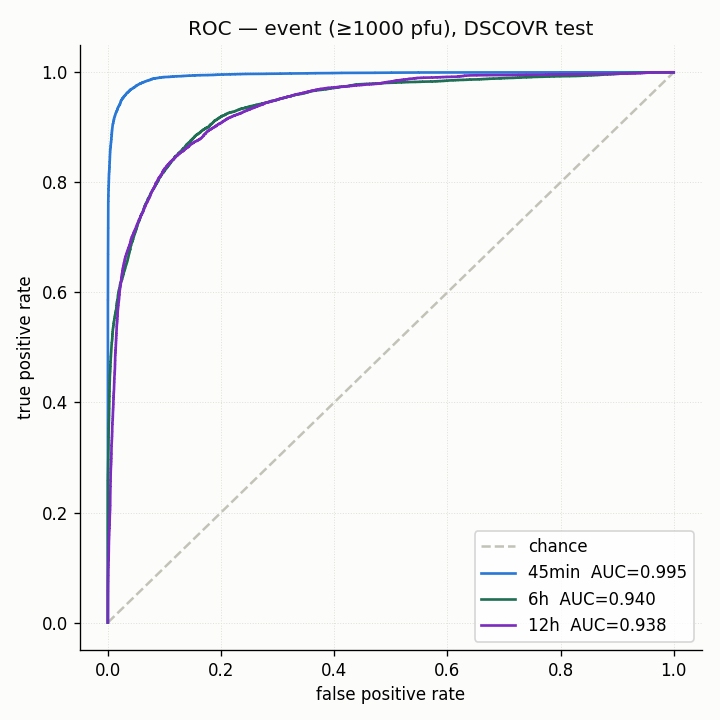

In [7]:
!python phase3/retrain.py            # retrain B+C on raw DSCOVR L1 -> phase3/artifacts + metrics
!python phase3/plots.py              # skill bars, forecast-vs-actual, reliability, ROC
!python phase3/predict.py            # live forecast + Risk Score -> operational condition (latest row)
from IPython.display import Image, display
for p in ['p3_skill_bars.png', 'p3_pred_vs_actual.png', 'p3_reliability.png', 'p3_roc.png']:
    display(Image(f'phase3/artifacts/{p}'))